# Getting Started with PullbackDMDc

This notebook shows a minimal, runnable example of using `PullbackDMDc` via `utils/pullback_dmdc.py`.

It covers:
- creating synthetic climate-like data and forcings,
- fitting a Pullback DMDc model,
- estimating the forced response (with plots),
- computing rotated modes (with plots),
- saving/loading the fitted model with pickle.

In [1]:
import pickle
from pathlib import Path

import numpy as np, scipy, matplotlib.pyplot as plt

from utils.pullback_dmdc import PullbackDMDc

In [2]:
# Reproducible synthetic example with low-dimensional latent dynamics
rng = np.random.default_rng(7)
n_time = 500
n_space = 50
lag = 2
truncation = 20
transition_time = 200

# Two mean-centered forcing channels, including the transition time
#long_forcings = np.cumsum(rng.normal(scale=0.05, size=(n_time+transition_time, 2)), axis=0)
phi = np.exp(-1/50.)
long_forcings = scipy.signal.lfilter([1], [1, -phi], rng.normal(scale=np.sqrt(1-phi**2), size=(n_time+transition_time, 2)), axis=0)
long_forcings = long_forcings - long_forcings[transition_time:].mean(axis=0)  # Mean-center the forcing
short_forcings = long_forcings[transition_time:]  # Short forcing is a subset of the long forcing

# Build latent features driven by previous state + forcing
n_features = 6
features = np.zeros((n_time+transition_time, n_features))
A = np.diag(np.linspace(0.6, 0.95, n_features))
B = rng.normal(scale=0.1, size=(n_features, 2))
for t in range(lag, n_time+transition_time):
    features[t] = A @ features[t - lag] + B @ long_forcings[t] + rng.normal(scale=0.4, size=n_features)
# Observed interval
features=features[transition_time:,:]
features=features - features.mean(axis=0)  # Mean-center the features

# Project latent state to gridded space
basis = rng.normal(size=(n_features, n_space))
data = features @ basis + rng.normal(scale=0.2, size=(n_time, n_space))


In [3]:
# The model does not include the intercept term, so we always mean-center the data and forcings
model = PullbackDMDc(truncation=truncation, lag=lag, transition_time=transition_time)
model.fit(data, short_forcings=short_forcings, long_forcings=long_forcings)
forced_response = model.predict()

print('Forced response shape:', forced_response.shape)
print('A matrix shape:', model.A.shape)
print('B matrix shape:', model.B.shape)

Forced response shape: (500, 50)
A matrix shape: (20, 20)
B matrix shape: (20, 2)


In [4]:
rot = model.compute_rotated_modes(top_n=6)
print('Rotated spatial patterns:', rot['spatial_patterns'].shape)
print('Rotated forced time series:', rot['forced_time_series'].shape)
print('Rotated internal time series:', rot['internal_time_series'].shape)
print('First two labels:', rot['labels'])

Rotated spatial patterns: (50, 6)
Rotated forced time series: (500, 6)
Rotated internal time series: (500, 6)
First two labels: [('1', 'real'), ('2,3', 'complex'), ('2,3', 'complex'), ('4', 'real'), ('5', 'real'), ('6', 'real')]


In [5]:
# Save and reload a fitted model object
out_dir = Path('evaluation_results')
out_dir.mkdir(exist_ok=True)
out_file = out_dir / 'example_pullbackdmdc_model.pkl'

with out_file.open('wb') as f:
    pickle.dump(model, f)

with out_file.open('rb') as f:
    loaded = pickle.load(f)

print('Saved model to', out_file)
print('Loaded model type:', type(loaded).__name__)

Saved model to evaluation_results/example_pullbackdmdc_model.pkl
Loaded model type: PullbackDMDc


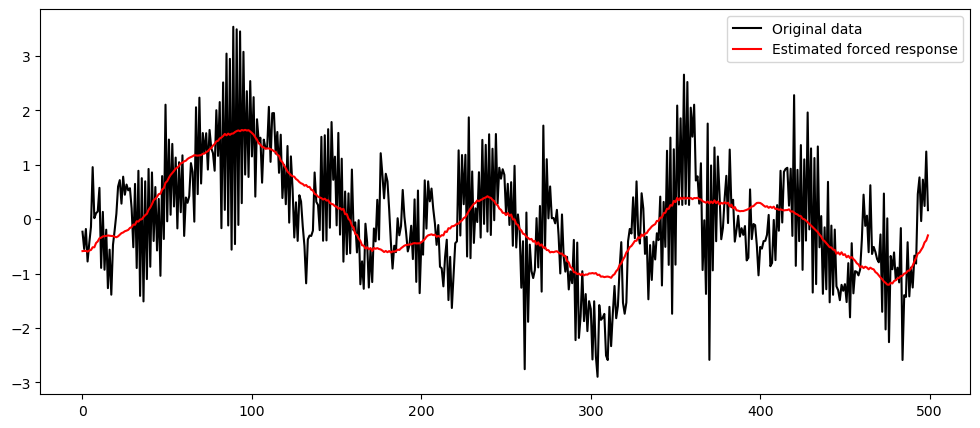

In [6]:
# plot the original data and the estimated forced response
k=10 # data channel to plot
plt.figure(figsize=(12, 5))
plt.plot(data[:,k], label='Original data', color='black')
plt.plot(forced_response[:,k], label='Estimated forced response', color='red')
plt.legend()
plt.show()

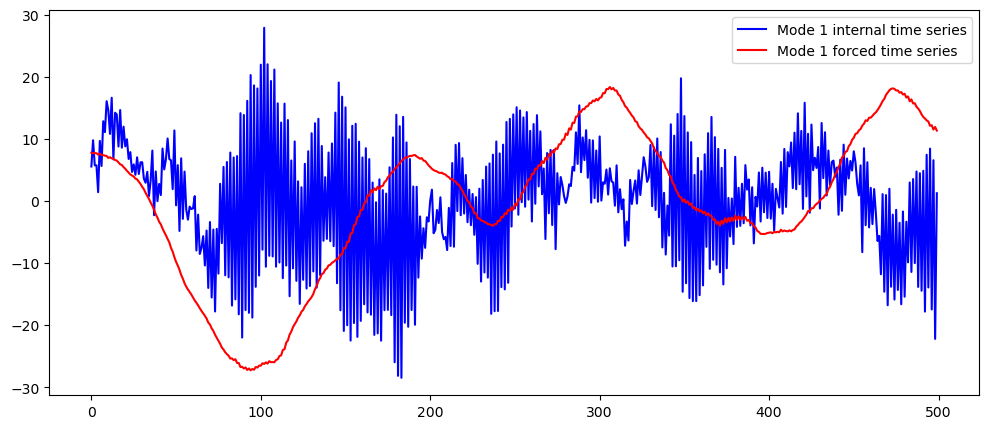

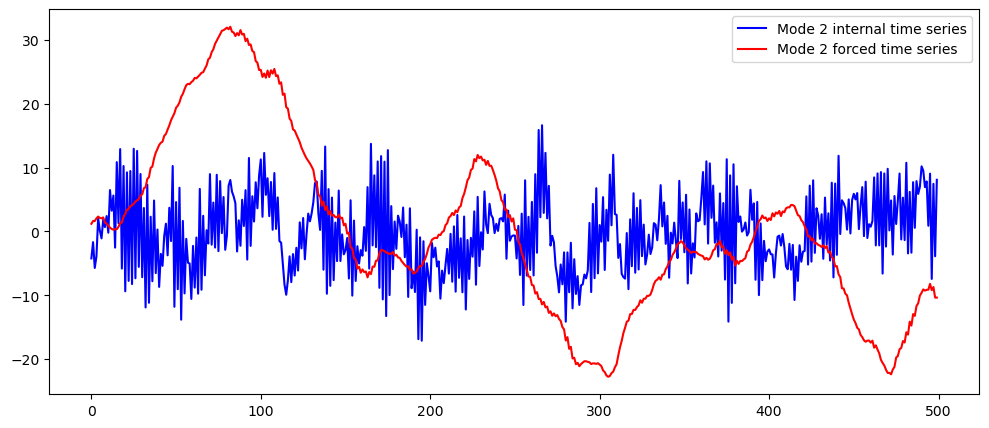

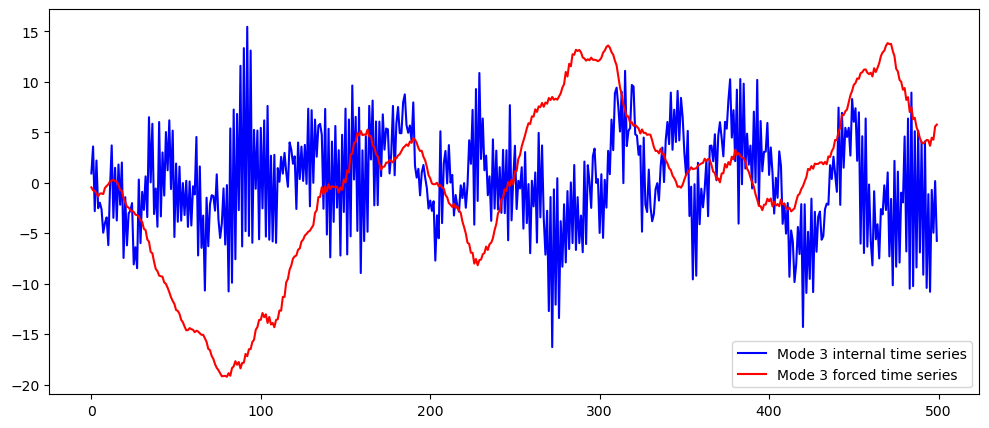

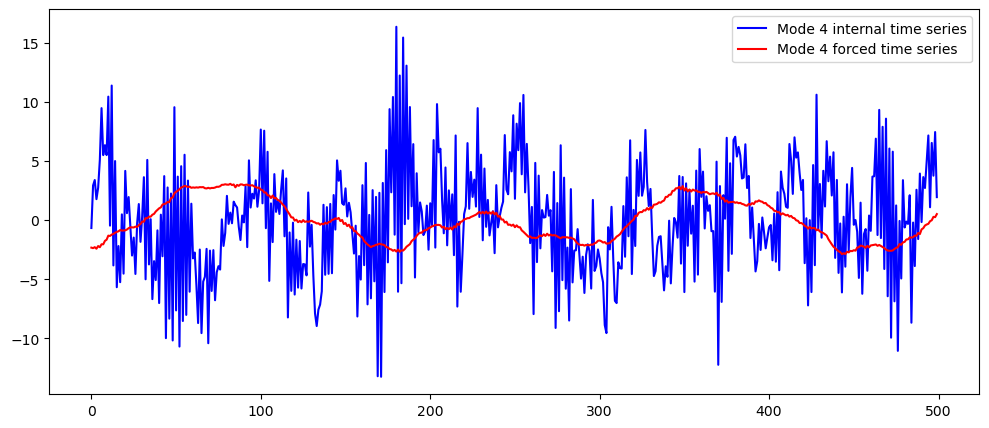

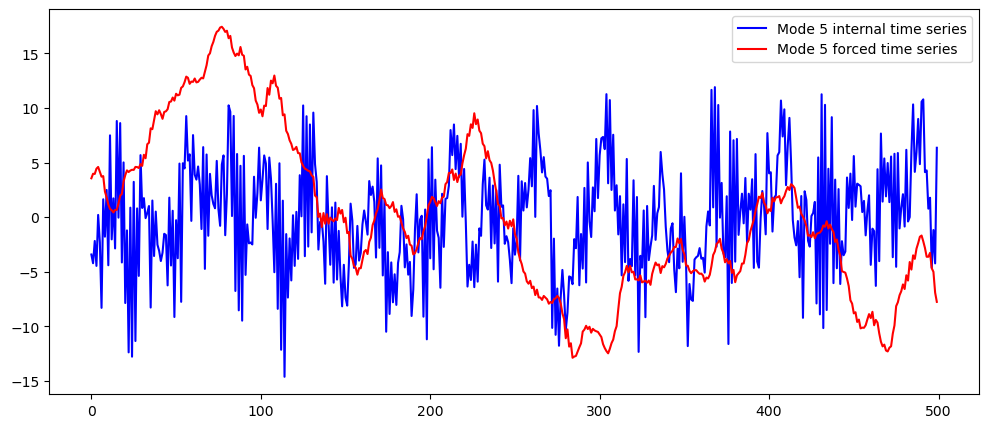

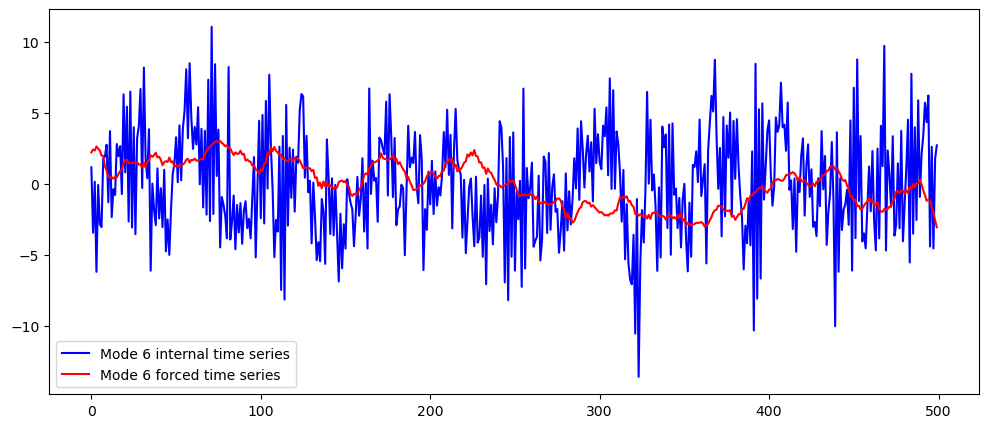

In [7]:
# plot leading mode time series
for j in range(6):
    plt.figure(figsize=(12, 5))
    plt.plot(rot['internal_time_series'][:,j], label=f'Mode {j+1} internal time series', color='blue')
    plt.plot(rot['forced_time_series'][:,j], label=f'Mode {j+1} forced time series', color='red')
    plt.legend()
    plt.show()